In [1]:
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [2]:
CSV_PATH = "raw_wholesale_customers.csv"
OUT_PATH = "segmented_wholesale_customers.csv"
FEATURES = ["Fresh", "Milk", "Grocery", 
            "Frozen", "Detergents_Paper", "Delicassen"]
RANDOM_STATE = 42

In [3]:
# --------------------------------
# 1) Load dataset
# --------------------------------
df = pd.read_csv("raw_wholesale_customers.csv")

print("\n=== INITIAL SNAPSHOT ===")
print(df.head())



=== INITIAL SNAPSHOT ===
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [5]:
# --------------------------------
# 2) Select features + IQR cap
# L3: clip extreme spend values before scaling
# --------------------------------
X = df[FEATURES].copy()

def iqr_fun(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

low_fresh,  high_fresh = iqr_fun(X["Fresh"])
low_milk,    high_milk = iqr_fun(X["Milk"])
low_grocery, high_grocery = iqr_fun(X["Grocery"])
low_frozen,  high_frozen = iqr_fun(X["Frozen"])
low_det,     high_det = iqr_fun(X["Detergents_Paper"])
low_deli,    high_deli = iqr_fun(X["Delicassen"])

X["Fresh"] = X["Fresh"].clip(lower=low_fresh,  upper=high_fresh)
X["Milk"] = X["Milk"].clip(lower=low_milk,    upper=high_milk)
X["Grocery"] = X["Grocery"].clip(lower=low_grocery, upper=high_grocery)
X["Frozen"] = X["Frozen"].clip(lower=low_frozen,  upper=high_frozen)
X["Detergents_Paper"] = X["Detergents_Paper"].clip(lower=low_det, upper=high_det)
X["Delicassen"] = X["Delicassen"].clip(lower=low_deli, upper=high_deli)

df[FEATURES] = X
    


In [6]:
print("\n=== IQR CAP SUMMARY FOR EACH FEATURE ===")
print(f"Fresh              low={low_fresh:.2f}  high={high_fresh:.2f}  |  after cap min={X['Fresh'].min():.2f}  max={X['Fresh'].max():.2f}")
print(f"Milk               low={low_milk:.2f}  high={high_milk:.2f}  |  after cap min={X['Milk'].min():.2f}  max={X['Milk'].max():.2f}")
print(f"Grocery            low={low_grocery:.2f}  high={high_grocery:.2f}  |  after cap min={X['Grocery'].min():.2f}  max={X['Grocery'].max():.2f}")
print(f"Frozen             low={low_frozen:.2f}  high={high_frozen:.2f}  |  after cap min={X['Frozen'].min():.2f}  max={X['Frozen'].max():.2f}")
print(f"Detergents_Paper   low={low_det:.2f}  high={high_det:.2f}  |  after cap min={X['Detergents_Paper'].min():.2f}  max={X['Detergents_Paper'].max():.2f}")
print(f"Delicassen         low={low_deli:.2f}  high={high_deli:.2f}  |  after cap min={X['Delicassen'].min():.2f}  max={X['Delicassen'].max():.2f}")

print("\n=== FEATURES HEAD (after IQR cap) ===")
print(X.head())


=== IQR CAP SUMMARY FOR EACH FEATURE ===
Fresh              low=-17581.25  high=37642.75  |  after cap min=3.00  max=37642.75
Milk               low=-6952.88  high=15676.12  |  after cap min=55.00  max=15676.12
Grocery            low=-10601.12  high=23409.88  |  after cap min=3.00  max=23409.88
Frozen             low=-3475.75  high=7772.25  |  after cap min=25.00  max=7772.25
Detergents_Paper   low=-5241.12  high=9419.88  |  after cap min=3.00  max=9419.88
Delicassen         low=-1709.75  high=3938.25  |  after cap min=3.00  max=3938.25

=== FEATURES HEAD (after IQR cap) ===
     Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669.0  9656.0   7561.0   214.0            2674.0     1338.00
1   7057.0  9810.0   9568.0  1762.0            3293.0     1776.00
2   6353.0  8808.0   7684.0  2405.0            3516.0     3938.25
3  13265.0  1196.0   4221.0  6404.0             507.0     1788.00
4  22615.0  5410.0   7198.0  3915.0            1777.0     3938.25


In [7]:
# --------------------------------
# 3) Scale features (StandardScaler)
# --------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nScaled shape (StandardScaler):", X_scaled.shape)



Scaled shape (StandardScaler): (440, 6)


In [13]:
import warnings
warnings.filterwarnings("ignore")
# --------------------------------
# 4) Elbow method (print SSE)
# --------------------------------
K = 3

print("\n=== ELBOW METHOD (SSE per k) ===")
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE)
    km.fit(X_scaled)
    print(f"k={k} → SSE={km.inertia_:.2f}")




=== ELBOW METHOD (SSE per k) ===
k=1 → SSE=2640.00
k=2 → SSE=1728.19
k=3 → SSE=1363.45
k=4 → SSE=1202.41
k=5 → SSE=1070.15
k=6 → SSE=964.76
k=7 → SSE=921.14
k=8 → SSE=776.63
k=9 → SSE=726.88
k=10 → SSE=707.41


In [14]:
# --------------------------------
# 5) Fit K-Means with chosen k
# --------------------------------
kmeans = KMeans(n_clusters=K, n_init="auto", random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels.astype(int)
print("\n=== SAMPLE WITH K-MEANS CLUSTERS ===")
print(df.head())



=== SAMPLE WITH K-MEANS CLUSTERS ===
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   
3        1       3  13265.0  1196.0   4221.0  6404.0             507.0   
4        2       3  22615.0  5410.0   7198.0  3915.0            1777.0   

   Delicassen  Cluster  
0     1338.00        1  
1     1776.00        0  
2     3938.25        2  
3     1788.00        2  
4     3938.25        2  


In [15]:
# --------------------------------
# 6) Evaluate clustering
# --------------------------------
sil = silhouette_score(X_scaled, labels)
dbi = davies_bouldin_score(X_scaled, labels)
print("\n=== K-MEANS METRICS ===")
print(f"Silhouette Score : {sil:.3f} (closer to +1 is better)")
print(f"Davies–Bouldin   : {dbi:.3f} (lower is better)")



=== K-MEANS METRICS ===
Silhouette Score : 0.340 (closer to +1 is better)
Davies–Bouldin   : 1.297 (lower is better)


In [16]:
# --------------------------------
# 7) Cluster centers (back to original units)
# --------------------------------
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(centers_original, columns=FEATURES)
centers_df.index.name = "Cluster"

print("\n=== CLUSTER CENTERS (Original Units) ===")
print(centers_df.round(2))



=== CLUSTER CENTERS (Original Units) ===
            Fresh      Milk   Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                     
0         5869.23  10142.25  16653.32  1355.63           7022.05     1482.60
1         9418.37   2685.47   3583.98  2052.33            942.49      750.71
2        22881.83   5870.35   6773.44  5057.43           1209.38     2452.04


In [17]:

# --------------------------------
# 8) Second Algorithm + Different Scaler
# --------------------------------
# Apply a different scaler for contrast (MinMaxScaler)
minmax_scaler = MinMaxScaler()
X_scaled_minmax = minmax_scaler.fit_transform(X)

# Initialize and train Agglomerative Clustering
agg_model = AgglomerativeClustering(n_clusters=K, metric='euclidean', linkage='ward')
agg_labels = agg_model.fit_predict(X_scaled_minmax)

df["Cluster_Agglomerative"] = agg_labels.astype(int)

sil_agg = silhouette_score(X_scaled_minmax, agg_labels)
dbi_agg = davies_bouldin_score(X_scaled_minmax, agg_labels)

print("\n=== AGGLOMERATIVE CLUSTERING METRICS (MinMaxScaler) ===")
print(f"Silhouette Score : {sil_agg:.3f}")
print(f"Davies–Bouldin   : {dbi_agg:.3f}")



=== AGGLOMERATIVE CLUSTERING METRICS (MinMaxScaler) ===
Silhouette Score : 0.277
Davies–Bouldin   : 1.493


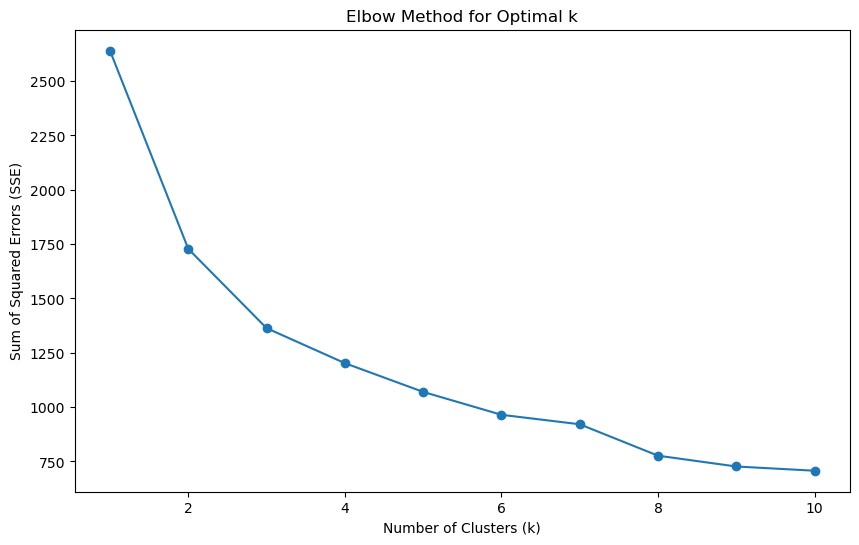

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
k_values = list(range(1, 11))
sse_values = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE)
    km.fit(X_scaled)
    sse_values.append(km.inertia_)

plt.plot(k_values, sse_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [19]:
# --------------------------------
# 9) Sanity checks (3 clients)
# --------------------------------
sample_idx = [0, 1, 2]
sanity = df.loc[sample_idx, ["Channel", "Region"] + FEATURES + ["Cluster", "Cluster_Agglomerative"]]
print("\n=== SANITY CHECK (3 Clients) ===")
print(sanity)



=== SANITY CHECK (3 Clients) ===
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   

   Delicassen  Cluster  Cluster_Agglomerative  
0     1338.00        1                      0  
1     1776.00        0                      0  
2     3938.25        2                      2  


In [20]:
# --------------------------------
# 10) Save labeled dataset
# --------------------------------
df.to_csv(OUT_PATH, index=False)
print(f"\Segmented clustered dataset → {OUT_PATH}")

\Segmented clustered dataset → segmented_wholesale_customers.csv
